
# AI Laboratory: Evolutionary Computation

This notebook is a simple and educational introduction to **Evolutionary Computation (EC)**.

It covers:

- what evolutionary computation is
- the basic workflow of an evolutionary algorithm
- common solution representations
- example objective functions for each representation
- two important types of evolutionary algorithms
- a final guided problem using **binary representation**

---



## 1. Learning goals

By the end of this lab, you should be able to:

1. explain the main idea of evolutionary computation
2. describe how a population of candidate solutions evolves
3. recognize different ways to represent solutions
4. define an objective function for a given problem
5. distinguish between two important types of evolutionary algorithms
6. design a simple binary-encoded evolutionary algorithm

Evolutionary computation is one of those human inventions where we copy nature because apparently nature had a few good ideas before optimization textbooks existed.



## 2. What is Evolutionary Computation?

**Evolutionary Computation (EC)** is a family of optimization and search methods inspired by biological evolution.

Instead of trying to directly build the perfect solution, EC starts with a **population** of candidate solutions and improves them over multiple generations.

The main ideas are:

- **Population**: many candidate solutions exist at the same time
- **Fitness / objective function**: each solution is evaluated
- **Selection**: better solutions are more likely to be chosen
- **Variation**: new solutions are created by mutation and recombination
- **Replacement**: a new generation is formed
- **Termination**: the process stops after a number of generations or when a good solution is found

### General workflow

1. Initialize a random population  
2. Evaluate all individuals  
3. Select parents  
4. Apply variation operators  
5. Build a new population  
6. Repeat until a stopping condition is reached  
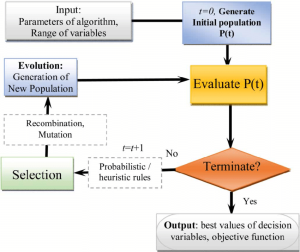

This is useful when:

- the search space is very large
- the problem is complex or nonlinear
- derivatives are unavailable
- we only need a good solution, not necessarily a perfect one


In [ ]:

# A very high-level pseudocode for an evolutionary algorithm

population = initialize_population()

for generation in range(max_generations):
    fitness_values = evaluate(population)
    parents = select(population, fitness_values)
    offspring = recombine_and_mutate(parents)
    population = replace(population, offspring)

best_solution = get_best(population)
print("Best solution found:", best_solution)



## 3. Concepts

### Individual
A single candidate solution.

### Chromosome / genome
The encoded form of a solution.

### Gene
A component of the chromosome.

### Population
A set of individuals.

### Fitness / objective function
A numerical score showing how good a solution is.

### Mutation
A small random change in one individual.

### Crossover / recombination
Combining information from two or more parents.

### Selection
Choosing better individuals more often.

These are the usual moving parts. 



## 4. Common representations of solutions

The representation must match the problem. A poor representation makes optimization harder, even if the algorithm itself is good.

We will study five common representations:

1. binary
2. real-valued
3. integer
4. permutation
5. tree representation for mathematical expressions

and others...



## 4.1 Binary representation

A solution is encoded as a string of bits (0 and 1).

### Example
Suppose we want to choose whether 5 items are included in a solution:

$$x = [1, 0, 1, 1, 0]$$

Meaning:

- item 1: selected
- item 2: not selected
- item 3: selected
- item 4: selected
- item 5: not selected

### Typical use
- subset selection
- feature selection
- knapsack-type problems
- yes/no decision problems

### Example objective function
For a simple maximization problem:

$$f(x) = \sum_{i=1}^{n} x_i$$

This counts how many 1s exist in the chromosome.

If we use binary encoding for a knapsack problem:

$$f(x) = \sum_{i=1}^{n} v_i x_i$$

subject to:

$$\sum_{i=1}^{n} w_i x_i \leq W$$

where:
- $v_i$ = value of item $i$
- $w_i$ = weight of item $i$
- $W$ = maximum capacity


In [3]:

# Binary representation example
x = [1, 0, 1, 1, 0]

# Objective: maximize the number of 1s
f = sum(x)
print("Binary solution:", x)
print("Objective value:", f)


Binary solution: [1, 0, 1, 1, 0]
Objective value: 3



## 4.2 Real-valued representation

A solution is represented using real numbers.

### Example

$$x = [2.5, -1.2, 0.75]$$

### Typical use
- continuous optimization
- parameter tuning
- engineering design
- machine learning hyperparameters

### Example objective function
A classical minimization example:

$$f(x) = x_1^2 + x_2^2 + x_3^2$$

The goal is to find values close to zero.

More generally:

$$f(x) = \sum_{i=1}^{n} x_i^2$$

This is a simple sphere-like function, widely used for teaching optimization.


In [4]:

# Real-valued representation example
x = [2.5, -1.2, 0.75]

f = sum(value**2 for value in x)
print("Real-valued solution:", x)
print("Objective value:", f)


Real-valued solution: [2.5, -1.2, 0.75]
Objective value: 8.2525



## 4.3 Integer representation

A solution is represented using integers.

### Example

$$x = [3, 1, 4, 2]$$

### Typical use
- scheduling
- allocation
- resource assignment
- discrete parameter optimization

### Example objective function
Suppose we want the values to be close to a target vector $[2, 2, 2, 2]$:

$$f(x) = \sum_{i=1}^{n} (x_i - 2)^2$$

The goal is to minimize the distance from the target.

Another example could be maximizing a weighted integer sum:

$$f(x) = 4x_1 + 2x_2 + 7x_3 + x_4$$


In [5]:

# Integer representation example
x = [3, 1, 4, 2]

f = sum((value - 2)**2 for value in x)
print("Integer solution:", x)
print("Objective value:", f)


Integer solution: [3, 1, 4, 2]
Objective value: 6



## 4.4 Permutation representation

A solution is an ordered arrangement of elements.

### Example
$$x = [3, 1, 4, 2, 5]$$

This can represent the order in which cities are visited.

### Typical use
- Traveling Salesperson Problem (TSP)
- job sequencing
- ordering tasks
- routing

### Example objective function
For a route optimization problem, minimize the total travel distance:

$$f(x) = d(x_1, x_2) + d(x_2, x_3) + \dots + d(x_{n-1}, x_n) + d(x_n, x_1)$$

where $d(a, b)$ is the distance between city $a$ and city $b$.

Important note: in permutation problems, standard bit-flip mutation or ordinary crossover may create invalid permutations, so specialized operators are needed.


In [6]:

# Permutation representation example
# Suppose we have a very small distance matrix for 4 cities

distance = [
    [0, 2, 9, 10],
    [1, 0, 6, 4],
    [15, 7, 0, 8],
    [6, 3, 12, 0]
]

route = [0, 2, 3, 1]  # a permutation of the cities

def route_length(route, distance):
    total = 0
    for i in range(len(route) - 1):
        total += distance[route[i]][route[i + 1]]
    total += distance[route[-1]][route[0]]  # return to start
    return total

print("Permutation solution:", route)
print("Route length:", route_length(route, distance))


Permutation solution: [0, 2, 3, 1]
Route length: 21



## 4.5 Tree representation for a mathematical expression

In **Genetic Programming (GP)**, a solution can be represented as a **tree**.

### Example expression
$$(x + 2) \times (x - 3)$$

This can be represented as a tree:

- root: multiplication
- left subtree: $x + 2$
- right subtree: $x - 3$

### Typical use
- symbolic regression
- automatic program generation
- rule discovery
- expression optimization

### Example objective function
Suppose we want a formula that approximates known data points $(x_i, y_i)$.
We can minimize the mean squared error:

$$f(T) = \frac{1}{m} \sum_{i=1}^{m} (T(x_i) - y_i)^2$$

where:
- $T$ is the expression tree
- $m$ is the number of data points

The lower the error, the better the tree.


In [7]:

# Tree-like expression example (simulated in Python with a function)

def tree_expression(x):
    return (x + 2) * (x - 3)

data = [(-1, 0), (0, -6), (1, -6), (2, -4)]
mse = sum((tree_expression(x) - y)**2 for x, y in data) / len(data)

print("Mean squared error of the expression tree:", mse)


Mean squared error of the expression tree: 4.0



## 5. Summary of representations and objective functions

| Representation | Example | Typical problems | Example objective function |
|---|---|---|---|
| Binary | `[1,0,1,1,0]` | subset selection, knapsack | $f(x)=\sum x_i$ or knapsack value |
| Real-valued | `[2.5,-1.2,0.75]` | continuous optimization | $f(x)=\sum x_i^2$ |
| Integer | `[3,1,4,2]` | scheduling, allocation | $f(x)=\sum (x_i-2)^2$ |
| Permutation | `[3,1,4,2,5]` | routing, sequencing | total route length |
| Tree | expression tree | symbolic regression | mean squared error |

The message is simple: **the representation determines which operators are appropriate**.



## 6. Two important types of evolutionary algorithms

There are many families of evolutionary computation, but two very important ones are:

### 6.1 Genetic Algorithms (GA)

Genetic Algorithms usually work with:
- binary strings
- discrete encodings
- crossover as a major operator

Typical components:
- binary or integer representation
- tournament or roulette-wheel selection
- one-point or two-point crossover
- mutation with small probability

GA is very common in education because it is intuitive and easy to implement.

### 6.2 Evolution Strategies (ES)

Evolution Strategies usually work with:
- real-valued vectors
- continuous parameters
- mutation as a major operator

Typical components:
- real-valued representation
- Gaussian mutation
- survivor selection such as $(\mu, \lambda)$ or $(\mu + \lambda)$

ES is often used for continuous optimization.

### Short comparison

| Feature | Genetic Algorithm | Evolution Strategies |
|---|---|---|
| Typical encoding | binary / discrete | real-valued |
| Main focus | crossover + mutation | mutation-driven search |
| Common usage | combinatorial problems | continuous optimization |

Other important EC families also exist, such as **Genetic Programming**, **Differential Evolution**, and **Evolutionary Programming**. Humans, unable to leave a good acronym alone, created many variants.



## 7. Final guided problem: 0/1 Knapsack with binary representation

We now build a simple evolutionary algorithm for the **0/1 Knapsack Problem**.

### Problem statement

We have several items. Each item has:
- a **value**
- a **weight**

We want to choose items that:
- maximize total value
- do not exceed the maximum capacity of the knapsack

---



## Step 1. Representation

We use a **binary representation**.

If there are $n$ items, then a solution is:

$$x = [x_1, x_2, \dots, x_n]$$

where:
- $x_i = 1$ means item $i$ is selected
- $x_i = 0$ means item $i$ is not selected

### Example
If we have 5 items:

$$x = [1, 0, 1, 0, 1]$$

then items 1, 3, and 5 are included.



## Step 2. Objective function

Let:
- $v_i$ = value of item $i$
- $w_i$ = weight of item $i$
- $W$ = capacity

The total value is:

$$
\text{value}(x) = \sum_{i=1}^{n} v_i x_i
$$

The total weight is:

$$
\text{weight}(x) = \sum_{i=1}^{n} w_i x_i
$$

We want to maximize value while respecting the constraint:

$$
\text{weight}(x) \leq W
$$

### Practical handling of infeasible solutions

A simple approach is to use a **penalty**:

$$
f(x) =
\begin{cases}
\sum_{i=1}^{n} v_i x_i, & \text{if } \sum_{i=1}^{n} w_i x_i \leq W \\
0, & \text{otherwise}
\end{cases}
$$

This is easy to understand and implement.



## Step 3. Variation operators for binary representation

### 3.1 Mutation
For binary chromosomes, the typical mutation is **bit-flip mutation**.

Example:

$$
[1, 0, 1, 1, 0] \rightarrow [1, 0, 0, 1, 0]
$$

One bit changes from 1 to 0 or from 0 to 1.

### 3.2 Selection
Typical selection methods:
- tournament selection
- roulette-wheel selection

For a beginner-friendly implementation, **tournament selection** is often the easiest.

**Tournament selection idea:**
1. randomly choose a few individuals
2. keep the best one
3. repeat until enough parents are selected

### 3.3 Combination (crossover)
For binary chromosomes, typical crossover methods are:
- one-point crossover
- two-point crossover
- uniform crossover

Example of one-point crossover:

Parent 1:
$$
[1, 1, 0, 0, 1]
$$

Parent 2:
$$
[0, 0, 1, 1, 0]
$$

Cut after the second position:

Child 1:
$$
[1, 1, 1, 1, 0]
$$

Child 2:
$$
[0, 0, 0, 0, 1]
$$



## Step 4. Guide to build the whole program

A simple program can follow these stages:

### A. Define the problem data
- list of item values
- list of item weights
- capacity of the knapsack

### B. Generate an initial population
- create many random binary vectors

### C. Evaluate the population
- compute fitness for every chromosome

### D. Select parents
- use tournament selection

### E. Create offspring
- apply crossover
- apply mutation

### F. Build the next generation
- replace the old population with offspring
- optionally keep the best individual (elitism)

### G. Repeat
- run for a fixed number of generations

### H. Return the best solution
- best chromosome
- total value
- total weight


In [8]:

# Problem data for the final exercise

values = [10, 6, 8, 4, 12, 7]
weights = [4, 2, 3, 1, 6, 2]
capacity = 10

n_items = len(values)

print("Values :", values)
print("Weights:", weights)
print("Capacity:", capacity)


Values : [10, 6, 8, 4, 12, 7]
Weights: [4, 2, 3, 1, 6, 2]
Capacity: 10


In [9]:

import random

def random_individual(n):
    return [random.randint(0, 1) for _ in range(n)]

def compute_weight(individual, weights):
    return sum(bit * w for bit, w in zip(individual, weights))

def compute_value(individual, values):
    return sum(bit * v for bit, v in zip(individual, values))

def fitness(individual, values, weights, capacity):
    total_weight = compute_weight(individual, weights)
    total_value = compute_value(individual, values)
    if total_weight <= capacity:
        return total_value
    return 0  # penalty for infeasible solutions

# Example
ind = random_individual(n_items)
print("Individual:", ind)
print("Weight:", compute_weight(ind, weights))
print("Value:", compute_value(ind, values))
print("Fitness:", fitness(ind, values, weights, capacity))


Individual: [0, 1, 0, 0, 1, 0]
Weight: 8
Value: 18
Fitness: 18


In [10]:

def tournament_selection(population, fitnesses, k=3):
    selected_indices = random.sample(range(len(population)), k)
    best_index = max(selected_indices, key=lambda i: fitnesses[i])
    return population[best_index][:]  # return a copy

def one_point_crossover(parent1, parent2):
    point = random.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

def bit_flip_mutation(individual, mutation_rate=0.05):
    mutated = individual[:]
    for i in range(len(mutated)):
        if random.random() < mutation_rate:
            mutated[i] = 1 - mutated[i]
    return mutated

# Operator demo
p1 = random_individual(n_items)
p2 = random_individual(n_items)
c1, c2 = one_point_crossover(p1, p2)
m1 = bit_flip_mutation(c1, mutation_rate=0.2)

print("Parent 1:", p1)
print("Parent 2:", p2)
print("Child 1 :", c1)
print("Child 2 :", c2)
print("Mutated :", m1)


Parent 1: [0, 0, 0, 1, 1, 0]
Parent 2: [0, 1, 0, 0, 1, 0]
Child 1 : [0, 1, 0, 0, 1, 0]
Child 2 : [0, 0, 0, 1, 1, 0]
Mutated : [0, 1, 0, 0, 1, 0]



## Step 5. Complete example program

The following code implements a simple binary Genetic Algorithm for the knapsack problem.

Read it carefully and identify:
- where the population is initialized
- where fitness is computed
- where selection happens
- where crossover happens
- where mutation happens
- how the next generation is formed


In [11]:

def genetic_algorithm_knapsack(values, weights, capacity,
                               population_size=20,
                               generations=30,
                               crossover_rate=0.8,
                               mutation_rate=0.05,
                               tournament_k=3):

    n = len(values)

    # 1. Initialize population
    population = [random_individual(n) for _ in range(population_size)]

    best_solution = None
    best_fitness = -1

    for generation in range(generations):
        # 2. Evaluate population
        fitnesses = [fitness(ind, values, weights, capacity) for ind in population]

        # Update global best
        generation_best_index = max(range(population_size), key=lambda i: fitnesses[i])
        generation_best = population[generation_best_index]
        generation_best_fitness = fitnesses[generation_best_index]

        if generation_best_fitness > best_fitness:
            best_fitness = generation_best_fitness
            best_solution = generation_best[:]

        # 3. Create next generation
        new_population = []

        # Elitism: keep the best individual
        new_population.append(generation_best[:])

        while len(new_population) < population_size:
            # 4. Selection
            parent1 = tournament_selection(population, fitnesses, k=tournament_k)
            parent2 = tournament_selection(population, fitnesses, k=tournament_k)

            # 5. Crossover
            if random.random() < crossover_rate:
                child1, child2 = one_point_crossover(parent1, parent2)
            else:
                child1, child2 = parent1[:], parent2[:]

            # 6. Mutation
            child1 = bit_flip_mutation(child1, mutation_rate)
            child2 = bit_flip_mutation(child2, mutation_rate)

            # 7. Add offspring
            new_population.append(child1)
            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population

        print(f"Generation {generation + 1:2d}: best fitness = {best_fitness}")

    return best_solution, best_fitness


In [12]:

best_solution, best_fitness = genetic_algorithm_knapsack(
    values, weights, capacity,
    population_size=20,
    generations=30,
    crossover_rate=0.8,
    mutation_rate=0.05,
    tournament_k=3
)

best_weight = compute_weight(best_solution, weights)
best_value = compute_value(best_solution, values)

print("\nBest solution found:", best_solution)
print("Total weight:", best_weight)
print("Total value :", best_value)
print("Fitness     :", best_fitness)


Generation  1: best fitness = 27
Generation  2: best fitness = 27
Generation  3: best fitness = 27
Generation  4: best fitness = 27
Generation  5: best fitness = 27
Generation  6: best fitness = 27
Generation  7: best fitness = 27
Generation  8: best fitness = 27
Generation  9: best fitness = 27
Generation 10: best fitness = 27
Generation 11: best fitness = 27
Generation 12: best fitness = 27
Generation 13: best fitness = 27
Generation 14: best fitness = 27
Generation 15: best fitness = 27
Generation 16: best fitness = 27
Generation 17: best fitness = 27
Generation 18: best fitness = 27
Generation 19: best fitness = 27
Generation 20: best fitness = 27
Generation 21: best fitness = 27
Generation 22: best fitness = 27
Generation 23: best fitness = 27
Generation 24: best fitness = 27
Generation 25: best fitness = 27
Generation 26: best fitness = 27
Generation 27: best fitness = 27
Generation 28: best fitness = 27
Generation 29: best fitness = 27
Generation 30: best fitness = 27

Best solu


## 8. Student tasks

1. Change the mutation rate and observe the effect.
2. Change the population size.
3. Try two-point crossover instead of one-point crossover.
4. Replace the penalty value `0` with a stronger penalty formula.
5. Add a stopping rule based on no improvement.
6. Plot the best fitness over generations.



In [27]:

# Optional extension: track the best fitness per generation

def genetic_algorithm_knapsack_with_history(values, weights, capacity,
                                            population_size=24,
                                            generations=30,
                                            crossover_rate=0.8,
                                            mutation_rate=0.5,
                                            tournament_k=3):
    n = len(values)
    population = [random_individual(n) for _ in range(population_size)]

    best_solution = None
    best_fitness = -1
    history = []

    for generation in range(generations):
        fitnesses = [fitness(ind, values, weights, capacity) for ind in population]
        generation_best_index = max(range(population_size), key=lambda i: fitnesses[i])
        generation_best = population[generation_best_index]
        generation_best_fitness = fitnesses[generation_best_index]

        if generation_best_fitness > best_fitness:
            best_fitness = generation_best_fitness
            best_solution = generation_best[:]

        history.append(best_fitness)

        new_population = [generation_best[:]]
        while len(new_population) < population_size:
            parent1 = tournament_selection(population, fitnesses, k=tournament_k)
            parent2 = tournament_selection(population, fitnesses, k=tournament_k)

            if random.random() < crossover_rate:
                child1, child2 = one_point_crossover(parent1, parent2)
            else:
                child1, child2 = parent1[:], parent2[:]

            child1 = bit_flip_mutation(child1, mutation_rate)
            child2 = bit_flip_mutation(child2, mutation_rate)

            new_population.append(child1)
            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population

    return best_solution, best_fitness, history


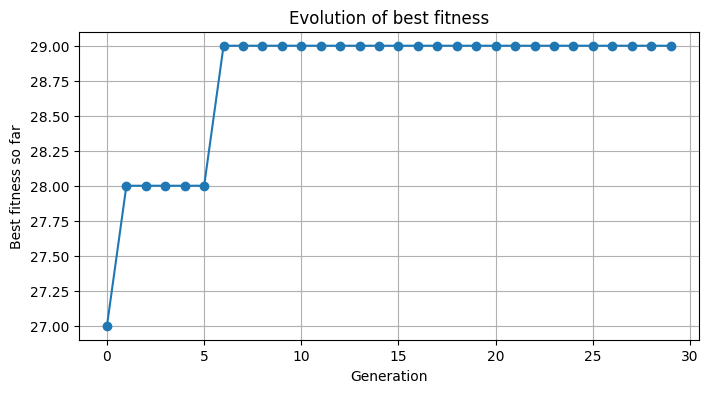

In [28]:

# Optional plot
import matplotlib.pyplot as plt

best_solution, best_fitness, history = genetic_algorithm_knapsack_with_history(
    values, weights, capacity,
    population_size=24,
    generations=30,
    crossover_rate=0.8,
    mutation_rate=0.5,
    tournament_k=3
)

plt.figure(figsize=(8, 4))
plt.plot(history, marker='o')
plt.xlabel("Generation")
plt.ylabel("Best fitness so far")
plt.title("Evolution of best fitness")
plt.grid(True)
plt.show()


In [29]:
def two_point_crossover(parent1, parent2):
    point1 = random.randint(1, len(parent1) - 2)
    point2 = random.randint(point1 + 1, len(parent1) - 1)
    child1 = parent1[:point1] + parent2[point1:point2] + parent1[point2:]
    child2 = parent2[:point1] + parent1[point1:point2] + parent2[point2:]
    return child1, child2

def genetic_algorithm_knapsack_with_history(values, weights, capacity,
                                            population_size=24,
                                            generations=30,
                                            crossover_rate=0.8,
                                            mutation_rate=0.5,
                                            tournament_k=3):
    n = len(values)
    population = [random_individual(n) for _ in range(population_size)]

    best_solution = None
    best_fitness = -1
    history = []

    for generation in range(generations):
        fitnesses = [fitness(ind, values, weights, capacity) for ind in population]
        generation_best_index = max(range(population_size), key=lambda i: fitnesses[i])
        generation_best = population[generation_best_index]
        generation_best_fitness = fitnesses[generation_best_index]

        if generation_best_fitness > best_fitness:
            best_fitness = generation_best_fitness
            best_solution = generation_best[:]

        history.append(best_fitness)

        new_population = [generation_best[:]]
        while len(new_population) < population_size:
            parent1 = tournament_selection(population, fitnesses, k=tournament_k)
            parent2 = tournament_selection(population, fitnesses, k=tournament_k)

            if random.random() < crossover_rate:
                child1, child2 = two_point_crossover(parent1, parent2)
            else:
                child1, child2 = parent1[:], parent2[:]

            child1 = bit_flip_mutation(child1, mutation_rate)
            child2 = bit_flip_mutation(child2, mutation_rate)

            new_population.append(child1)
            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population

    return best_solution, best_fitness, history

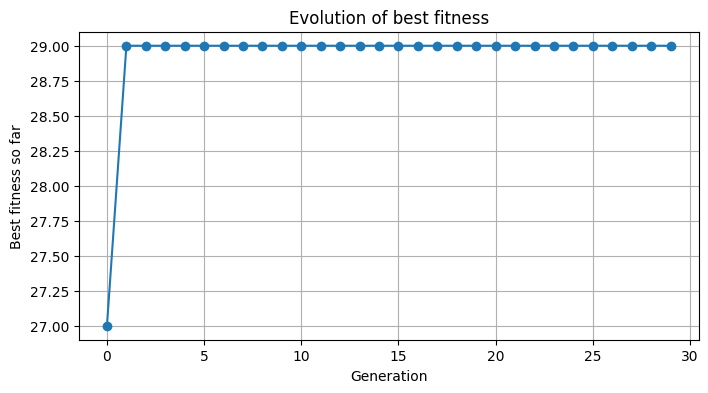

In [30]:

# Optional plot
import matplotlib.pyplot as plt

best_solution, best_fitness, history = genetic_algorithm_knapsack_with_history(
    values, weights, capacity,
    population_size=24,
    generations=30,
    crossover_rate=0.8,
    mutation_rate=0.5,
    tournament_k=3
)

plt.figure(figsize=(8, 4))
plt.plot(history, marker='o')
plt.xlabel("Generation")
plt.ylabel("Best fitness so far")
plt.title("Evolution of best fitness")
plt.grid(True)
plt.show()


In [33]:
def fitness2(individual, values, weights, capacity):
    total_value = sum(individual[i] * values[i] for i in range(len(individual)))
    total_weight = sum(individual[i] * weights[i] for i in range(len(individual)))

    if total_weight > capacity:
        excess = total_weight - capacity
        penalty = total_value * (excess / capacity)  # proportional penalty
        return max(0, total_value - penalty)

    return total_value

def genetic_algorithm_knapsack_with_history(values, weights, capacity,
                                            population_size=24,
                                            generations=30,
                                            crossover_rate=0.8,
                                            mutation_rate=0.5,
                                            tournament_k=3):
    n = len(values)
    population = [random_individual(n) for _ in range(population_size)]

    best_solution = None
    best_fitness = -1
    history = []

    for generation in range(generations):
        fitnesses = [fitness2(ind, values, weights, capacity) for ind in population]
        generation_best_index = max(range(population_size), key=lambda i: fitnesses[i])
        generation_best = population[generation_best_index]
        generation_best_fitness = fitnesses[generation_best_index]

        if generation_best_fitness > best_fitness:
            best_fitness = generation_best_fitness
            best_solution = generation_best[:]

        history.append(best_fitness)

        new_population = [generation_best[:]]
        while len(new_population) < population_size:
            parent1 = tournament_selection(population, fitnesses, k=tournament_k)
            parent2 = tournament_selection(population, fitnesses, k=tournament_k)

            if random.random() < crossover_rate:
                child1, child2 = one_point_crossover(parent1, parent2)
            else:
                child1, child2 = parent1[:], parent2[:]

            child1 = bit_flip_mutation(child1, mutation_rate)
            child2 = bit_flip_mutation(child2, mutation_rate)

            new_population.append(child1)
            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population

    return best_solution, best_fitness, history


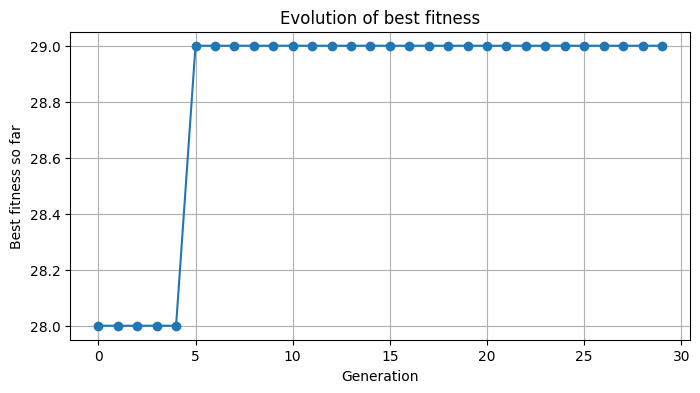

In [34]:

# Optional plot
import matplotlib.pyplot as plt

best_solution, best_fitness, history = genetic_algorithm_knapsack_with_history(
    values, weights, capacity,
    population_size=24,
    generations=30,
    crossover_rate=0.8,
    mutation_rate=0.5,
    tournament_k=3
)

plt.figure(figsize=(8, 4))
plt.plot(history, marker='o')
plt.xlabel("Generation")
plt.ylabel("Best fitness so far")
plt.title("Evolution of best fitness")
plt.grid(True)
plt.show()


In [35]:
def genetic_algorithm_knapsack_with_history_patience(values, weights, capacity,
                                            population_size=24,
                                            generations=30,
                                            crossover_rate=0.8,
                                            mutation_rate=0.5,
                                            tournament_k=3,
                                            patience=10):
    n = len(values)
    population = [random_individual(n) for _ in range(population_size)]

    best_solution = None
    best_fitness = -1
    history = []
    no_improvement_count = 0

    for generation in range(generations):
        fitnesses = [fitness(ind, values, weights, capacity) for ind in population]
        generation_best_index = max(range(population_size), key=lambda i: fitnesses[i])
        generation_best = population[generation_best_index]
        generation_best_fitness = fitnesses[generation_best_index]

        if generation_best_fitness > best_fitness:
            best_fitness = generation_best_fitness
            best_solution = generation_best[:]
            no_improvement_count = 0
        else:
            no_improvement_count += 1

        history.append(best_fitness)

        if no_improvement_count >= patience:
            break

        new_population = [generation_best[:]]
        while len(new_population) < population_size:
            parent1 = tournament_selection(population, fitnesses, k=tournament_k)
            parent2 = tournament_selection(population, fitnesses, k=tournament_k)

            if random.random() < crossover_rate:
                child1, child2 = one_point_crossover(parent1, parent2)
            else:
                child1, child2 = parent1[:], parent2[:]

            child1 = bit_flip_mutation(child1, mutation_rate)
            child2 = bit_flip_mutation(child2, mutation_rate)

            new_population.append(child1)
            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population

    return best_solution, best_fitness, history

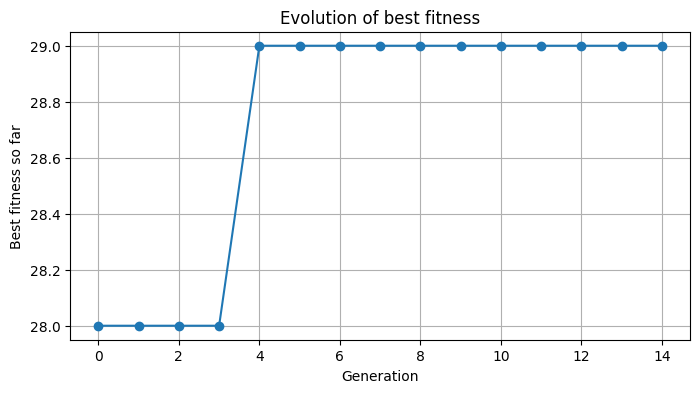

In [36]:

# Optional plot
import matplotlib.pyplot as plt

best_solution, best_fitness, history = genetic_algorithm_knapsack_with_history_patience(
    values, weights, capacity,
    population_size=24,
    generations=30,
    crossover_rate=0.8,
    mutation_rate=0.5,
    tournament_k=3,
    patience=10
)

plt.figure(figsize=(8, 4))
plt.plot(history, marker='o')
plt.xlabel("Generation")
plt.ylabel("Best fitness so far")
plt.title("Evolution of best fitness")
plt.grid(True)
plt.show()



## 9. Conclusion

Evolutionary computation is a flexible optimization framework inspired by biological evolution.

Main lessons from this lab:

- a solution must be represented in a suitable form
- the objective function measures solution quality
- selection favors better individuals
- mutation and crossover generate diversity
- different representations require different operators
- binary Genetic Algorithms are a good starting point for learning EC

For more advanced study, you can continue with:
- constrained optimization
- multi-objective evolutionary algorithms
- Genetic Programming
- Differential Evolution
- Evolution Strategies

---
**End of notebook**
